In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
class SubgraphState(TypedDict):
    input_text: str
    language: str
    translated_text: str

In [8]:
subGraph_llm = ChatOpenAI()

In [12]:
# define Nodes
def translate_node(state: SubgraphState):
    input = state["input_text"]
    language = state["language"]
    response = subGraph_llm.invoke(f"Translate the following text to {language}: {input}")
    return {"translated_text": response.content}


In [13]:
subgraph = StateGraph(SubgraphState)

subgraph.add_node("translate_node", translate_node)

subgraph.add_edge(START, "translate_node")
subgraph.add_edge("translate_node", END)

translate_agent = subgraph.compile()

In [14]:
res = translate_agent.invoke({"input_text": "Hello, how are you?", "language": "hindi"})
print(res)

{'input_text': 'Hello, how are you?', 'language': 'hindi', 'translated_text': 'नमस्ते, आप कैसे हैं?'}


In [15]:
# Parent graph
class ParentGraphState(TypedDict):
    question: str
    answer_eng: str
    answer_hindi: str

In [16]:
parent_llm = ChatOpenAI()

In [17]:
def generate_answer(state: ParentGraphState):
    question = state["question"]
    response = parent_llm.invoke(f"Answer the following question in English: {question}")
    return {"answer_eng": response.content}

def translate_answer(state: ParentGraphState):
    answer_eng = state["answer_eng"]
    subgraph_res = translate_agent.invoke({"input_text": answer_eng, "language": "hindi"})
    return {"answer_hindi": subgraph_res["translated_text"]}

In [19]:
parentgraph = StateGraph(ParentGraphState)

parentgraph.add_node("generate_answer", generate_answer)
parentgraph.add_node("translate_answer", translate_answer)

parentgraph.add_edge(START, "generate_answer")
parentgraph.add_edge("generate_answer", "translate_answer")
parentgraph.add_edge("translate_answer", END)

parent_agent = parentgraph.compile()

res = parent_agent.invoke({"question": "What is the capital of France?"})
print(res)

{'question': 'What is the capital of France?', 'answer_eng': 'The capital of France is Paris.', 'answer_hindi': 'फ्रांस की राजधानी पेरिस है।'}


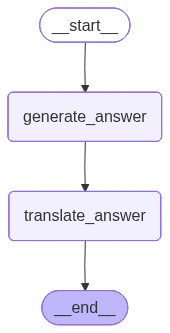

In [20]:
from IPython.display import Image

Image(parent_agent.get_graph().draw_mermaid_png())